In [2]:
from utils.logger import get_logger
from src.data_extractor.data_preparer import FlightDataPreparer, ModelType
from src.data_extractor.data_extractor import FlightDataExtractor
from src.models.reservoir_computing_model import IPReservoirComputingModel
from utils.io import read_csv_file
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [3]:
logger = get_logger("Trainer")

In [4]:
DATA_SUFFIX = "extra_large"
EXTRACT_DATA = False

In [5]:
if EXTRACT_DATA:
    AIR_CSV_LIST = [
        "./data/datasets/opensky/raw/states_2022-01-03-00.csv/states_2022-01-03-00.csv",
        "./data/datasets/opensky/raw/states_2022-01-03-01.csv/states_2022-01-03-01.csv",
    ]

    processor = FlightDataExtractor(
        metadata_file=f"./data/datasets/opensky/metadata/data_schema/dataset_{DATA_SUFFIX}_metadata.json",
        dataset_suffix=DATA_SUFFIX,
        base_path="./data/datasets/opensky/preprocessed",
        trans_path="./data/datasets/opensky/metadata/transformations"
    )
    processor.run_pipeline(AIR_CSV_LIST)

In [6]:
train_df = read_csv_file(f"./data/datasets/opensky/preprocessed/train/data_{DATA_SUFFIX}.csv")
val_df = read_csv_file(f"./data/datasets/opensky/preprocessed/val/data_{DATA_SUFFIX}.csv")
test_df = read_csv_file(f"./data/datasets/opensky/preprocessed/test/data_{DATA_SUFFIX}.csv")

display(train_df)
display(val_df)
display(test_df)

Successfully loaded CSV. Shape: (2227144, 16)
Successfully loaded CSV. Shape: (539590, 16)
Successfully loaded CSV. Shape: (489969, 16)


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,1.125218,-0.553913,0.435131,0.438556,-0.352960,2.659376,5.368318,-0.897729,-0.930259,0.632723,-0.774378,1641168010,0,0,0,3c4582.0
1,1.142489,0.198391,0.461729,-0.907274,0.088551,0.014306,0.121706,0.912355,0.826150,-0.966279,0.257497,1641168010,0,0,0,4ca8e8.0
2,0.554535,0.563995,0.443059,0.680354,0.922952,-0.035045,0.056123,1.057598,1.105374,0.790564,0.612380,1641168020,0,0,0,06a30c.0
3,0.015515,0.212421,-0.640967,-0.018416,-1.726665,0.014306,-0.337373,-1.814572,-1.791349,-0.014924,0.999889,1641168020,0,0,0,a81032.0
4,0.084167,-0.009877,-0.688867,-0.019034,0.486855,0.262669,0.056123,0.621870,0.642402,-0.907072,0.420975,1641168020,0,0,0,a0d561.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227139,0.442401,0.461426,-0.624973,0.646332,0.754326,0.244152,0.056123,0.694492,0.664020,0.839570,0.543251,1641175190,0,0,0,a2c1bd.1
2227140,0.308457,-0.009877,-0.832641,-0.019034,0.428855,0.014306,0.121706,0.767113,0.773908,-0.999526,-0.030791,1641175190,0,0,0,a11d47.3
2227141,-0.517281,-0.009877,1.728771,-0.019034,0.471152,0.014306,0.974280,-0.427507,-0.368208,0.252422,0.967617,1641175190,0,0,0,781b94.0
2227142,0.274200,-0.009877,1.784340,-0.019034,-0.115989,0.014306,-0.927617,-0.129760,-0.159240,-0.987530,-0.157432,1641175190,0,0,0,781157.2


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,0.454750,-0.412413,-0.376628,-0.187448,-1.390632,0.244421,-0.009460,-1.625757,-1.649035,-0.424720,-0.905325,1641168020,0,0,0,abea64.0
1,-0.230469,0.612409,-0.624549,-0.379125,0.236096,0.073044,0.056123,0.623686,0.678431,-0.590270,0.807206,1641168020,0,0,0,abb3b6.0
2,0.461195,0.435235,-0.380022,-0.084227,-1.496723,3.713178,1.039863,-1.678407,-1.697674,-0.145669,0.989333,1641168020,0,0,0,ab40ce.0
3,0.082941,-0.879007,-0.673333,0.881666,0.913257,0.186794,0.056123,0.694492,0.712659,0.776240,-0.630438,1641168020,0,0,0,ac205f.0
4,0.071096,-0.590651,-0.626919,-0.466928,0.881020,0.014306,-0.927617,0.164356,0.168623,-0.677505,-0.735518,1641168020,0,0,0,ab2729.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539585,0.686978,-0.194469,-0.649521,1.009214,1.182636,0.061706,0.056123,1.275461,1.199049,0.984745,-0.174003,1641175190,0,0,0,aae34c.0
539586,0.114476,-0.184051,-0.878382,0.399285,-0.645020,0.014306,0.056123,0.113522,0.134395,0.943914,-0.330191,1641175190,0,0,0,a9926b.1
539587,-0.155468,-0.006006,-0.586865,-0.347127,-0.462669,0.014306,0.121706,0.912355,0.968464,-0.999978,0.006601,1641175190,0,0,0,ababaf.1
539588,0.300470,0.379112,-0.508016,-0.618365,0.252691,0.014306,-0.009460,0.765297,0.746886,-0.867934,0.496679,1641175190,0,0,0,ab2504.0


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,-3.127935,-0.315133,-0.072904,-0.171713,-0.905581,0.014306,-0.730869,-1.266282,-1.249115,-0.553753,-0.832681,1641168020,0,0,0,e48003.0
1,-3.127148,0.630988,-0.073944,-0.428996,0.412256,-1.175492,-2.370435,-0.810584,-0.768129,-0.647648,0.761939,1641168020,0,0,0,e49329.0
2,0.217623,0.815193,-0.475728,-0.381478,0.873636,0.014306,0.056123,0.912355,0.927031,-0.454672,0.890659,1641168020,0,0,0,ad7760.0
3,0.249408,-0.482083,-0.823224,-0.474595,0.119701,-0.005107,0.056123,1.273646,1.281915,-0.740415,-0.672150,1641168020,0,0,0,ad5658.0
4,0.190320,-0.197598,-0.839459,-0.427605,-0.744223,-0.086250,-1.649026,-1.175505,-1.171652,-0.930797,-0.365536,1641168020,0,0,0,ac58b9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489964,0.568851,0.004412,-0.395118,1.103347,1.863746,0.014306,0.121706,0.549249,0.494684,0.999935,0.011400,1641175190,0,0,0,acf54f.1
489965,-3.894501,-0.173730,2.421444,-0.333773,-1.198772,1.665036,0.121706,-1.633019,-1.613006,-0.914013,-0.405685,1641175190,0,1,0,c818da.1
489966,-2.292795,-0.736216,0.034660,-0.335029,0.550138,0.014306,0.056123,0.912355,1.056735,-0.529179,-0.848510,1641175190,0,0,0,e07246.0
489967,-4.153812,-0.028294,2.416199,0.208550,-1.843287,0.582410,-0.075042,-1.420602,-1.405840,0.996428,-0.084443,1641175190,0,0,0,c805a0.2


In [7]:
data_preparer = FlightDataPreparer(target_column="velocity", window_size=12, required_length=100)

X_train_rc, y_train_rc, icao_list_train_rc = data_preparer.transform(train_df, model_type=ModelType.RESERVOIR_COMPUTING)
X_val_rc, y_val_rc, icao_list_val_rc = data_preparer.transform(val_df, model_type=ModelType.RESERVOIR_COMPUTING)
X_test_rc, y_test_rc, icao_list_test_rc = data_preparer.transform(test_df, model_type=ModelType.RESERVOIR_COMPUTING)

In [7]:
rc_params_default = {
    "units": 100,
    "sr": 0.9,
    "mu": 0.1,
    "input_scaling": 1,
    "learning_rate": 0.1,
    "rc_connectivity": 0.4,
    "input_connectivity": 0.4,
    "activation": "sigmoid",
    "epochs": 1000,
    "warmup_steps": 15,
    "ridge": 0.5,
    "seed": 33,
}
rc_model = IPReservoirComputingModel(name="rc_test", params=rc_params_default)
logger.info("Start fitting RC model")
rc_model.fit(X_train_rc, y_train_rc)
logger.info("RC model succesfully fitted")
y_pred_rc = rc_model.predict(X_test_rc)
logger.info(rc_model.evaluate(y_test_rc, y_pred_rc))
rc_model.save_model()

[2026-04-27 21:53:54] - INFO [Trainer]: Start fitting RC model


[2026-04-27 21:54:36] - INFO [IPReservoirComputingModel]: Training time: 41.21672773361206
[2026-04-27 21:54:36] - INFO [Trainer]: RC model succesfully fitted
[2026-04-27 21:54:45] - INFO [Trainer]: 0.6888437588754117
Successfully saved JSON to ./data/models\rc_test\1777319634\params.json. Items: 12
Successfully saved NPY to ./data/models\rc_test\1777319634\readout_weights.npy. Shape: (100, 1)
Successfully saved NPY to ./data/models\rc_test\1777319634\readout_bias.npy. Shape: (1,)


In [8]:
hpt_rc_model = IPReservoirComputingModel.tune(
    X_train=X_train_rc, 
    y_train=y_train_rc, 
    X_test=X_val_rc, 
    y_test=y_val_rc,
    name="hpt_rc",
    n_iterations=20,
    criterion=r2_score,
    optimize_objective="maximize"
)

{'units': np.int64(5), 'sr': np.float64(0.22383410687462496), 'mu': 0.22229075532659626, 'input_scaling': np.float64(0.010006705743063069), 'learning_rate': np.float64(6.038082917747018e-05), 'connectivity': 0.19498098696896418, 'activation': 'sigmoid', 'ridge': np.float64(0.6816496171469042), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}


c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))


New best score: 0.5143
Best params: {'units': np.int64(5), 'sr': '2.24e-01', 'mu': '2.22e-01', 'input_scaling': '1.00e-02', 'learning_rate': '6.04e-05', 'connectivity': '1.95e-01', 'activation': 'sigmoid', 'ridge': '6.82e-01', 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5, 'score': '5.14e-01'}
Iteration 1/20: Score = 0.5143
{'units': np.int64(5), 'sr': np.float64(0.22644611691813848), 'mu': np.float64(0.2368613667648203), 'input_scaling': np.float64(0.01055853985500679), 'learning_rate': np.float64(6.0287421346933656e-05), 'connectivity': np.float64(0.15843475850031805), 'activation': 'sigmoid', 'ridge': np.float64(0.6691334444481072), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}


c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python3

New best score: 0.5369
Best params: {'units': np.int64(5), 'sr': '2.26e-01', 'mu': '2.37e-01', 'input_scaling': '1.06e-02', 'learning_rate': '6.03e-05', 'connectivity': '1.58e-01', 'activation': 'sigmoid', 'ridge': '6.69e-01', 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5, 'score': '5.37e-01'}
Iteration 2/20: Score = 0.5369
{'units': np.int64(5), 'sr': np.float64(0.22607762004910065), 'mu': np.float64(0.28907220568377856), 'input_scaling': np.float64(0.009473012482151934), 'learning_rate': np.float64(4.83531320280975e-05), 'connectivity': np.float64(0.11087380823895397), 'activation': 'sigmoid', 'ridge': np.float64(0.7272576580905126), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}


...

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python

New best score: 0.9773
Best params: {'units': np.int64(100), 'sr': '5.46e-01', 'mu': '3.90e-01', 'input_scaling': '2.26e+00', 'learning_rate': '7.98e-03', 'connectivity': '2.13e-01', 'activation': 'sigmoid', 'ridge': '2.68e-01', 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5, 'score': '9.77e-01'}
Iteration 7/20: Score = 0.9773
{'units': np.int64(5), 'sr': np.float64(0.0257009345141994), 'mu': 0.07341255558548243, 'input_scaling': np.float64(0.22360646671015869), 'learning_rate': np.float64(3.074019367817181e-05), 'connectivity': 0.4421705926367344, 'activation': 'sigmoid', 'ridge': np.float64(0.1663201733933808), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 8/20: Score = 0.7670
{'units': np.int64(50), 'sr': np.float64(0.015082834851554832), 'mu': 0.3781388867609292, 'input_scaling': np.float64(0.007261457246146685), 'learning_rate': np.float64(0.0007233133919528955), 'connectivity': 0.2572997997479619, 'activation': 'sigmoid', 'ridge': np.float6

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))


Iteration 14/20: Score = 0.7073
{'units': np.int64(200), 'sr': np.float64(0.032581580866694666), 'mu': 0.3687022934482107, 'input_scaling': np.float64(0.0005276575446169548), 'learning_rate': np.float64(0.0004998986554805992), 'connectivity': 0.17341034609551226, 'activation': 'tanh', 'ridge': np.float64(0.0075828851307018705), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 15/20: Score = 0.9831
{'units': np.int64(200), 'sr': np.float64(0.01347061603948678), 'mu': np.float64(0.4136199339809221), 'input_scaling': np.float64(0.007446118287675047), 'learning_rate': np.float64(0.0008047285778759437), 'connectivity': np.float64(0.28208574756545957), 'activation': 'sigmoid', 'ridge': np.float64(3.764118712632011e-07), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
New best score: 0.9856
Best params: {'units': np.int64(200), 'sr': '1.35e-02', 'mu': '4.14e-01', 'input_scaling': '7.45e-03', 'learning_rate': '8.05e-04', 'connectivity': '2.82e-01', 'activat

c:\Users\camar\OneDrive\Escritorio\Master\TFM\reservoir-computing-flight-prediction\src\hpt\hp_visualizer.py:75: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(df[column], df['score'])


In [9]:
y_pred_hpt_rc = hpt_rc_model.predict(X_test_rc)
hpt_rc_model.evaluate(y_test_rc, y_pred_hpt_rc)

0.5435548349111602

In [ ]:
import torch
import torch.nn as nn

class R2ScoreLoss(nn.Module):
    def __init__(self):
        super(R2ScoreLoss, self).__init__()

    def forward(self, y_pred, y_true):
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()
        
        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
        
        r2 = 1 - (ss_res / (ss_tot + 1e-8))
        
        return 1 - r2
    
model_params_lstm = {
    "input_size": n_features_train,
    "hidden_size": 32,
    "num_layers": 2,
    "lr": 1e-4,
    "epochs": 100,
    "patience": 5,
    "device": device
}

model_lstm = LSTMRegressorModel(name="lstm_test", params=model_params_lstm, criterion=R2ScoreLoss(), optimize_objective="minimize")

model_lstm.fit(train_dataloader_lstm, val_dataloader_lstm)
y_true_lstm, y_pred_lstm = model_lstm.predict(test_dataloader_lstm)
logger.info(model_lstm.evaluate(y_true_lstm, y_pred_lstm))
model_lstm.save_model()

[2026-04-27 23:35:31] - INFO [LSTMRegressorModel]: Epoch 0 | Train Loss: 840936.698565 | Val Loss: 48692.023636
[2026-04-27 23:37:33] - INFO [LSTMRegressorModel]: Epoch 1 | Train Loss: 460649.069109 | Val Loss: 39458.509161


In [10]:
hpt_rc_model.params

{'units': np.int64(200),
 'sr': np.float64(0.01347061603948678),
 'mu': np.float64(0.4136199339809221),
 'input_scaling': np.float64(0.007446118287675047),
 'learning_rate': np.float64(0.0008047285778759437),
 'connectivity': np.float64(0.28208574756545957),
 'activation': 'sigmoid',
 'ridge': np.float64(3.764118712632011e-07),
 'epochs': 100,
 'warmup': 15,
 'seed': 12345,
 'n_instances': 5,
 'score': np.float64(0.9855963264343648)}

In [11]:
hpt_rc_model.save_model()

Successfully saved JSON to ./data/models\hpt_rc\1777324445\params.json. Items: 13
Successfully saved NPY to ./data/models\hpt_rc\1777324445\readout_weights.npy. Shape: (200, 1)
Successfully saved NPY to ./data/models\hpt_rc\1777324445\readout_bias.npy. Shape: (1,)


## LSTM

In [12]:
import torch
import torch.nn as nn
from src.models.lstm_model import LSTMRegressorModel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
data_preparer = FlightDataPreparer(target_column="velocity", window_size=12, required_length=100)

train_dataloader_lstm, n_features_train, icao_list_train_rc = data_preparer.transform(train_df, model_type=ModelType.LSTM)
val_dataloader_lstm, n_features_train, icao_list_train_rc = data_preparer.transform(val_df, model_type=ModelType.LSTM)
test_dataloader_lstm, n_features_test, icao_list_test_rc = data_preparer.transform(test_df, model_type=ModelType.LSTM)

In [ ]:
model_params_lstm = {
    "input_size": n_features_train,
    "hidden_size": 32,
    "num_layers": 2,
    "lr": 1e-4,
    "epochs": 100,
    "patience": 5,
    "device": device
}

model_lstm = LSTMRegressorModel(name="lstm_test", params=model_params_lstm,)

model_lstm.fit(train_dataloader_lstm, val_dataloader_lstm)
y_true_lstm, y_pred_lstm = model_lstm.predict(test_dataloader_lstm)
logger.info(model_lstm.evaluate(y_true_lstm, y_pred_lstm))
model_lstm.save_model()

[2026-04-27 23:40:52] - INFO [LSTMRegressorModel]: Epoch 0 | Train Loss: 0.616007 | Val Loss: 0.501416
[2026-04-27 23:42:41] - INFO [LSTMRegressorModel]: Epoch 1 | Train Loss: 0.511870 | Val Loss: 0.486181
[2026-04-27 23:44:30] - INFO [LSTMRegressorModel]: Epoch 2 | Train Loss: 0.493591 | Val Loss: 0.481803
[2026-04-27 23:46:19] - INFO [LSTMRegressorModel]: Epoch 3 | Train Loss: 0.484832 | Val Loss: 0.472032
[2026-04-27 23:48:07] - INFO [LSTMRegressorModel]: Epoch 4 | Train Loss: 0.475218 | Val Loss: 0.465827
[2026-04-27 23:49:55] - INFO [LSTMRegressorModel]: Epoch 5 | Train Loss: 0.469897 | Val Loss: 0.464312
[2026-04-27 23:51:44] - INFO [LSTMRegressorModel]: Epoch 6 | Train Loss: 0.463979 | Val Loss: 0.459358
[2026-04-27 23:53:32] - INFO [LSTMRegressorModel]: Epoch 7 | Train Loss: 0.454086 | Val Loss: 0.447406
[2026-04-27 23:55:21] - INFO [LSTMRegressorModel]: Epoch 8 | Train Loss: 0.442963 | Val Loss: 0.437319
[2026-04-27 23:57:09] - INFO [LSTMRegressorModel]: Epoch 9 | Train Loss: 

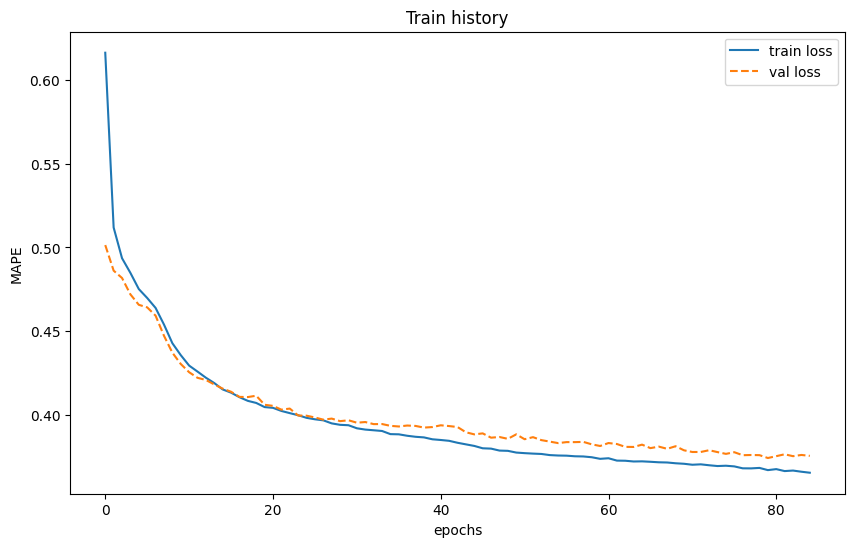

Plot rendered successfully.


In [21]:
model_lstm.plot_history()

In [ ]:
model_params_lstm = {
    "input_size": n_features_train,
    "hidden_size": 32,
    "num_layers": 2,
    "lr": 1e-4,
    "epochs": 100,
    "patience": 5,
    "device": device
}
model_lstm_mse = LSTMRegressorModel(name="lstm_test", params=model_params_lstm, criterion=nn.MSELoss())

model_lstm_mse.fit(train_dataloader_lstm, val_dataloader_lstm)
y_true_lstm_mse, y_pred_lstm_mse = model_lstm_mse.predict(test_dataloader_lstm)
logger.info(model_lstm_mse.evaluate(y_true_lstm, y_pred_lstm))
model_lstm_mse.save_model()

[2026-04-28 08:04:40] - INFO [LSTMRegressorModel]: Epoch 0 | Train Loss: 0.027430 | Val Loss: 0.013392
[2026-04-28 08:06:27] - INFO [LSTMRegressorModel]: Epoch 1 | Train Loss: 0.013279 | Val Loss: 0.012821
[2026-04-28 08:08:13] - INFO [LSTMRegressorModel]: Epoch 2 | Train Loss: 0.012784 | Val Loss: 0.012545
[2026-04-28 08:10:04] - INFO [LSTMRegressorModel]: Epoch 3 | Train Loss: 0.012508 | Val Loss: 0.012347
[2026-04-28 08:11:53] - INFO [LSTMRegressorModel]: Epoch 4 | Train Loss: 0.012317 | Val Loss: 0.012219
[2026-04-28 08:13:36] - INFO [LSTMRegressorModel]: Epoch 5 | Train Loss: 0.012180 | Val Loss: 0.012147
[2026-04-28 08:15:23] - INFO [LSTMRegressorModel]: Epoch 6 | Train Loss: 0.012075 | Val Loss: 0.012098
[2026-04-28 08:17:05] - INFO [LSTMRegressorModel]: Epoch 7 | Train Loss: 0.011983 | Val Loss: 0.012054
[2026-04-28 08:18:47] - INFO [LSTMRegressorModel]: Epoch 8 | Train Loss: 0.011906 | Val Loss: 0.012013
[2026-04-28 08:20:34] - INFO [LSTMRegressorModel]: Epoch 9 | Train Loss: 

In [ ]:
model_lstm_mse.plot_history()